# Garmin Race Prediction Analysis

### How did Garmin's race predictions evolve as my training became more serious?

### How did Garmin's race predictions evolve over time?

### When did predictions become stable?

### Did marathon predictions overshoot actual fitness?

### How did predictions react to: mileage spikes, marathon blocks, races, breaks?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# Looad parquet file into a pandas DataFrame
daily_master_table = pd.read_parquet('/Users/pabloherreramendez/Desktop/health_performance_project/data_processed/daily_master_v1.parquet')

# Print the shape of the daily master table
print(f'Shape of daily master table {daily_master_table.shape}')

Shape of daily master table (753, 49)


In [3]:
# Print the information of the daily master table
print(daily_master_table.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            753 non-null    datetime64[ns]
 1   run_count                       753 non-null    int64         
 2   total_distance_km               753 non-null    float64       
 3   total_distance_miles            753 non-null    float64       
 4   total_duration_minutes          753 non-null    float64       
 5   total_moving_minutes            753 non-null    float64       
 6   total_elevation_gain_m          753 non-null    float64       
 7   avg_hr                          738 non-null    float64       
 8   max_hr                          738 non-null    float64       
 9   avg_pace_mile                   753 non-null    float64       
 10  avg_power                       422 non-null    float64       
 11  max_po

In [4]:
# Print a description of the daily master table
print(daily_master_table.describe())

                                date   run_count  total_distance_km  \
count                            753  753.000000         753.000000   
mean   2024-07-19 20:06:41.593625344    1.373174          11.839911   
min              2016-11-13 00:00:00    1.000000           0.764540   
25%              2023-10-20 00:00:00    1.000000           6.896880   
50%              2024-10-05 00:00:00    1.000000          10.383250   
75%              2025-08-01 00:00:00    1.000000          16.113580   
max              2026-05-07 00:00:00    4.000000          42.550762   
std                              NaN    0.720278           7.038865   

       total_distance_miles  total_duration_minutes  total_moving_minutes  \
count            753.000000              753.000000            753.000000   
mean               7.356980               57.428514             56.309651   
min                0.475063                3.555600              0.000000   
25%                4.285522               35.638083 

In [5]:
# Need to convert prediction times to seconds in order to be used in analysis
predictions_type = ['5K_pred', '10K_pred', 'Half_pred', 'Marathon_pred']

for prediction in predictions_type:
    print("Current data type: ")
    print(type(prediction))
    print("Converting to minutes...")
    daily_master_table[prediction] = pd.to_timedelta(daily_master_table[prediction]) # minutes
    print('Conversion sucesful!')
    print(type(daily_master_table[prediction]))

    daily_master_table[prediction] = (
    pd.to_timedelta(daily_master_table[prediction])
    .dt.total_seconds() / 60
)

print(daily_master_table.info())

Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
Current data type: 
<class 'str'>
Converting to minutes...
Conversion sucesful!
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            753 non-null    datetime64[ns]
 1   run_count                       753 non-null    int64         
 2   total_distance_km               753 non-null    float64       
 3   total_distance_miles            753 non-null    float64       
 4   total_duration_min

In [6]:
# Print a random sample from the table to verify that everything looks correct
print(daily_master_table.sample(3)['5K_pred'])

720    17.2
290     NaN
100     NaN
Name: 5K_pred, dtype: float64


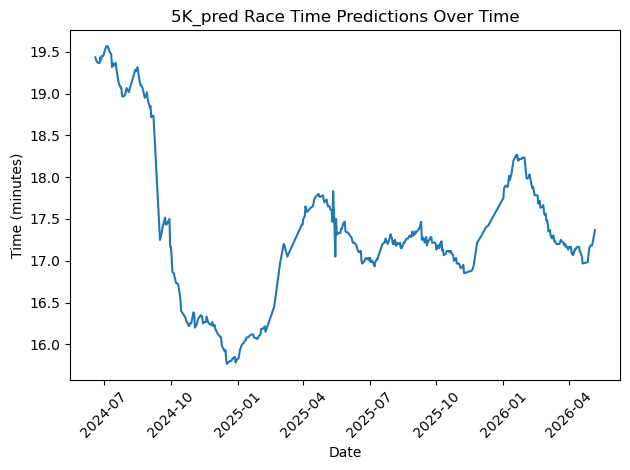

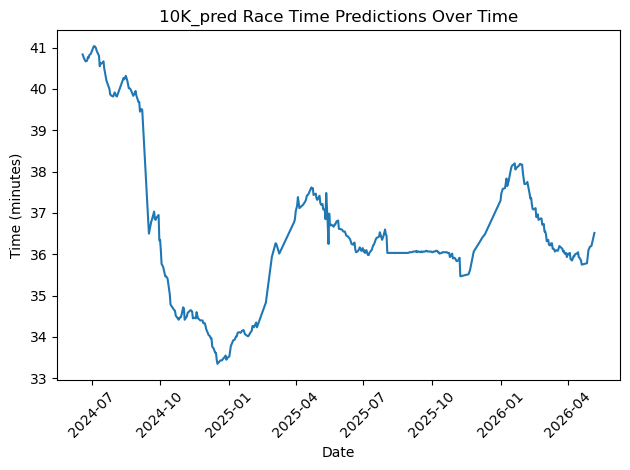

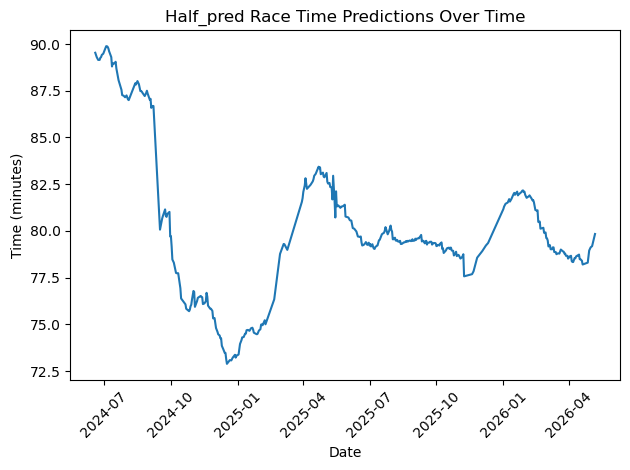

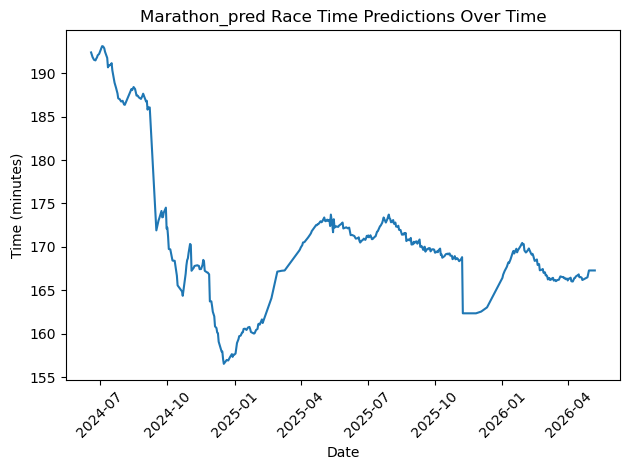

In [7]:
# Plot garmin race predictions over time
for prediction in predictions_type: 
    plt.figure
    sns.lineplot(data=daily_master_table, x='date', y=prediction)
    plt.title(f'{prediction} Race Time Predictions Over Time')
    plt.xlabel('Date')
    plt.ylabel('Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

First noteworth observation that can be seen in the data has to do with the a very fast decline in race predictions in 2024. Then the prediction times become incredily fast, which didn't accurately reflect my physical capability back then. I believe this may be due to me getting new Garmin hardware which introduced race prediction technology.

In [8]:
events_table = pd.read_csv('/Users/pabloherreramendez/Desktop/health_performance_project/data_raw/events_table.csv')
events_table['date'] = pd.to_datetime(events_table['date'])
print(events_table.info())
print(events_table)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               16 non-null     datetime64[ns]
 1   event_type         16 non-null     object        
 2   label              16 non-null     object        
 3   official_time_min  11 non-null     float64       
 4   race_type          11 non-null     object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 772.0+ bytes
None
         date            event_type                     label  \
0  2026-04-20                  race           Boston Marathon   
1  2026-01-07  training_block_start              Boston Build   
2  2025-11-09                  rest                      Rest   
3  2025-11-08                  race    Indiannapolis Marathon   
4  2025-08-04  training_block_start       Indiannapolis Build   
5  2025-08-02                  race       

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_19079/3207925791.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events_table['date'] = pd.to_datetime(events_table['date'])


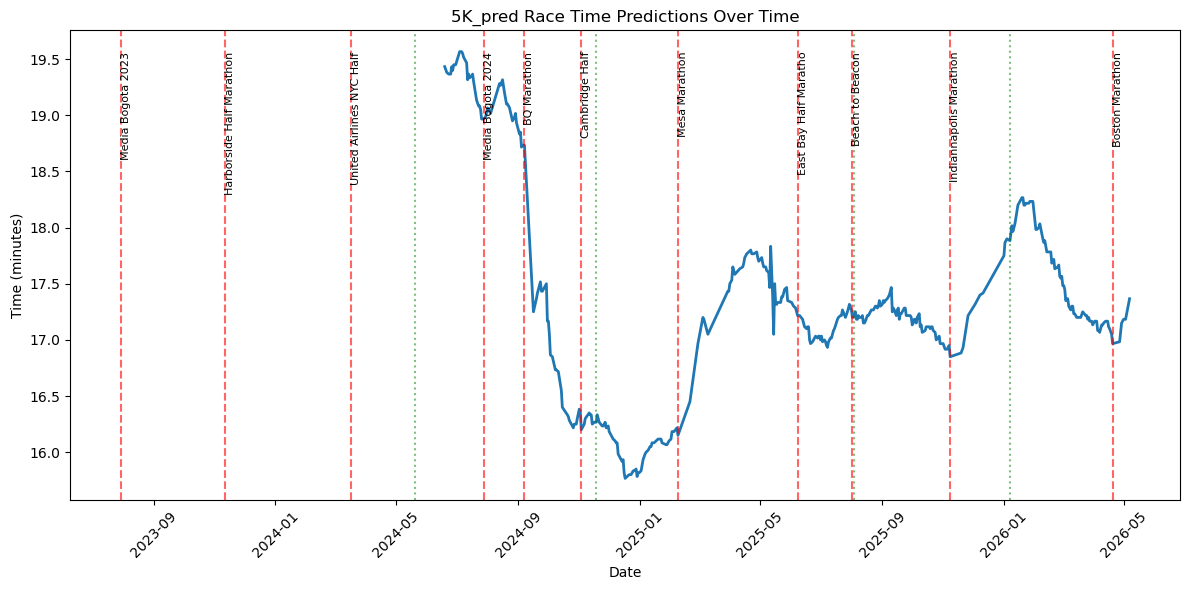

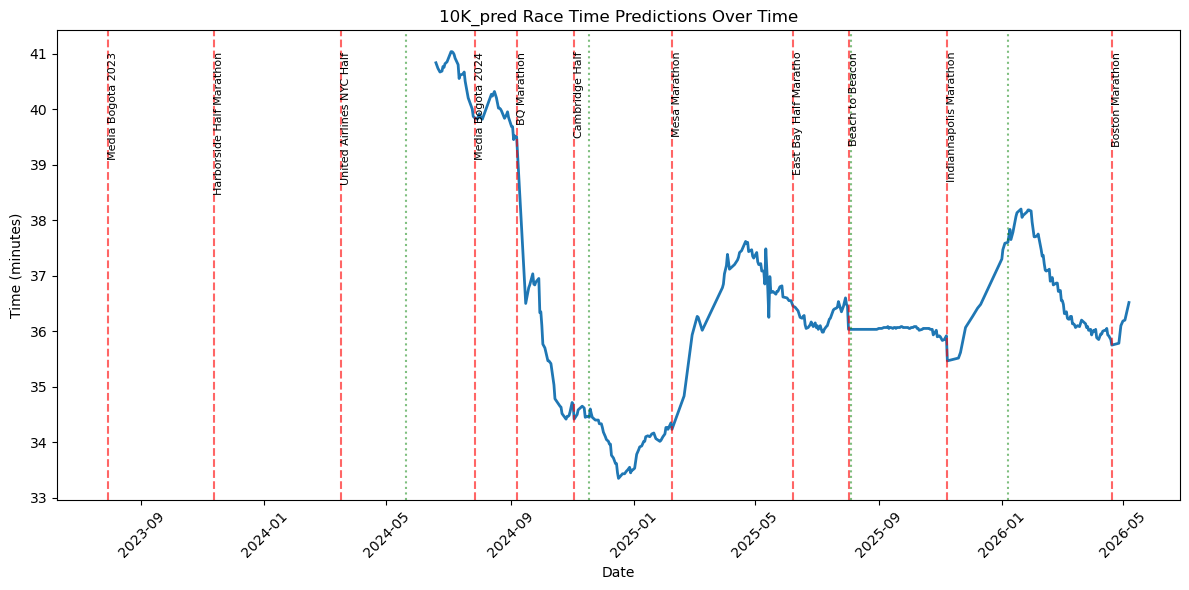

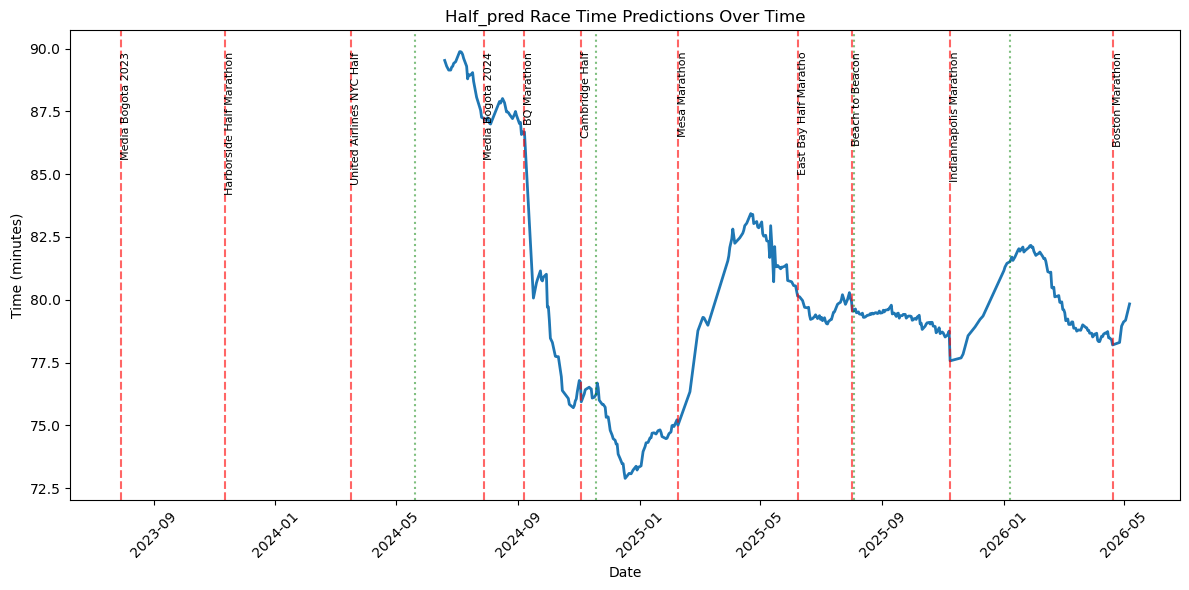

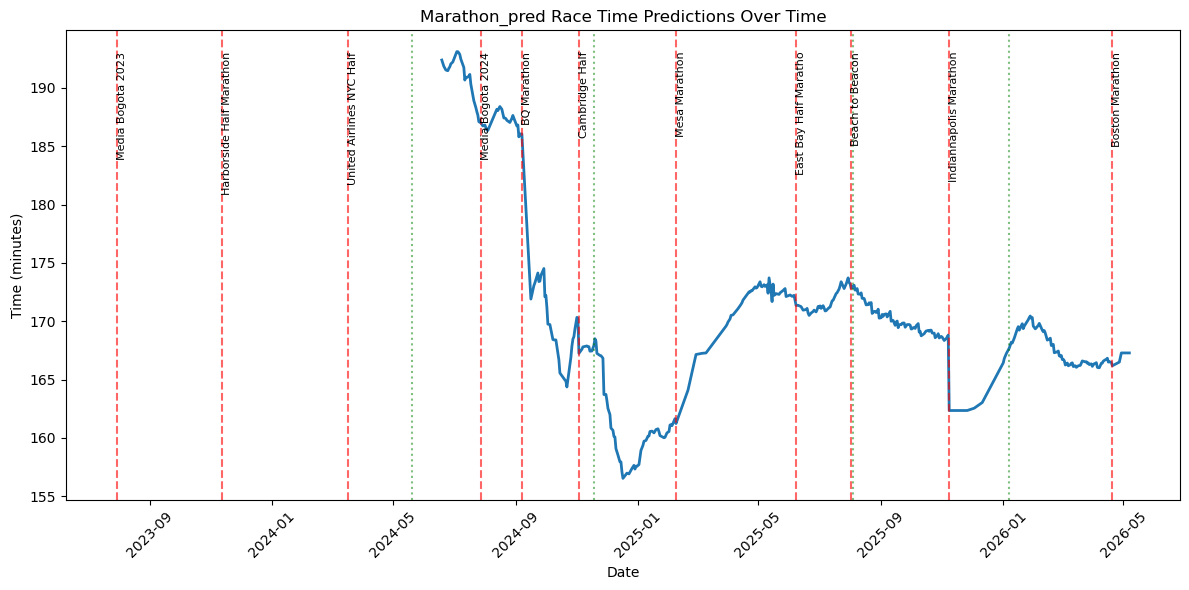

In [9]:
# Select races
race_events = events_table[
    events_table["event_type"] == "race"
]

# Select training block starts
block_events = events_table[
    events_table["event_type"] == "training_block_start"
]

# Plot predictions with race and block start markers
for prediction in predictions_type:

    plt.figure(figsize=(12, 6))

    # Prediction curve
    sns.lineplot(
        data=daily_master_table,
        x='date',
        y=prediction,
        linewidth=2
    )

    # Race markers
    for _, row in race_events.iterrows():
        plt.axvline(
            row["date"],
            color='red',
            linestyle='--',
            alpha=0.6
        )

        plt.text(
            row["date"],
            daily_master_table[prediction].max(),
            row["label"],
            rotation=90,
            fontsize=8,
            verticalalignment='top'
        )

    # Training block starts
    for _, row in block_events.iterrows():
        plt.axvline(
            row["date"],
            color='green',
            linestyle=':',
            alpha=0.5
        )

    plt.title(f'{prediction} Race Time Predictions Over Time')
    plt.xlabel('Date')
    plt.ylabel('Time (minutes)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

PREDICTION LEAKAGE: Predictions for race days actually take into account the race ran, so to make a meaningful comparison we need to observe the predictions from the day before the race.

In [10]:
# Create a predictions and actual time data frame

# Prediction date = day before race
race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)

# Select prediction columns
prediction_cols = [
    "date",
    "5K_pred",
    "10K_pred",
    "Half_pred",
    "Marathon_pred"
]

daily_sorted = daily_master_table.sort_values("date")
race_sorted = race_events.sort_values("prediction_date")

race_prediction_eval_df = pd.merge_asof(
    race_sorted,
    daily_sorted[prediction_cols],
    left_on="prediction_date",
    right_on="date",
    direction="backward"
)

race_prediction_eval_df = race_prediction_eval_df.rename(
    columns={"date_x": "race_date", "date_y": "prediction_date_matched"}
)

race_prediction_eval_df

/var/folders/5p/042l2mfn5lg_ltr5w11xxs9h0000gn/T/ipykernel_19079/1127184761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  race_events["prediction_date"] = race_events["date"] - pd.Timedelta(days=1)


,race_date,event_type,label,official_time_min,race_type,prediction_date,prediction_date_matched,5K_pred,10K_pred,Half_pred,Marathon_pred
0,2023-07-30,race,Media Bogota 2023,119.6300,half,2023-07-29,2023-07-23,NaN,NaN,NaN,NaN
1,2023-11-12,race,Harborside Half Marathon,87.2500,half,2023-11-11,2023-11-11,NaN,NaN,NaN,NaN
2,2024-03-17,race,United Airlines NYC Half,81.6800,half,2024-03-16,2024-03-16,NaN,NaN,NaN,NaN
3,2024-07-28,race,Media Bogota 2024,87.4670,half,2024-07-27,2024-07-26,18.966667,39.866667,87.266667,187.100000
4,2024-09-07,race,BQ Marathon,180.9330,marathon,2024-09-06,2024-09-05,18.733333,39.516667,86.683333,186.050000
5,2024-11-03,race,Cambridge Half,80.3000,half,2024-11-02,2024-11-02,16.366667,34.683333,76.733333,170.233333
6,2025-02-08,race,Mesa Marathon,169.2833,marathon,2025-02-07,2025-02-07,16.216667,34.350000,75.216667,161.650000
7,2025-06-08,race,East Bay Half Maratho,82.3500,half,2025-06-07,2025-06-06,17.283333,36.550000,80.550000,172.216667
8,2025-08-02,race,Beach to Beacon,36.5670,10k,2025-08-01,2025-08-01,17.266667,36.450000,79.966667,173.200000
9,2025-11-08,race,Indiannapolis Marathon,164.4800,marathon,2025-11-07,2025-11-07,16.950000,35.916667,78.750000,168.816667


In [12]:
# Prediction mapping
prediction_map = {
    "5k": "5K_pred",
    "10k": "10K_pred",
    "half": "Half_pred",
    "marathon": "Marathon_pred"
}

def get_relevant_prediction(row):
    pred_col = prediction_map.get(row["race_type"])
    
    if pred_col:
        return row[pred_col]
    
    return None

race_prediction_eval_df["relevant_prediction"] = (
    race_prediction_eval_df.apply(
        get_relevant_prediction,
        axis=1
    )
)

In [13]:
race_prediction_eval_df["prediction_error"] = (
    race_prediction_eval_df["relevant_prediction"]
    - race_prediction_eval_df["official_time_min"]
)

In [15]:
race_prediction_eval_df.groupby("race_type")[
    "prediction_error"
].agg(["mean", "std", "count"])

,mean,std,count
race_type,,,
10k,-0.117000,NaN,1
half,-1.855667,1.683857,3
marathon,-0.573992,6.295077,4


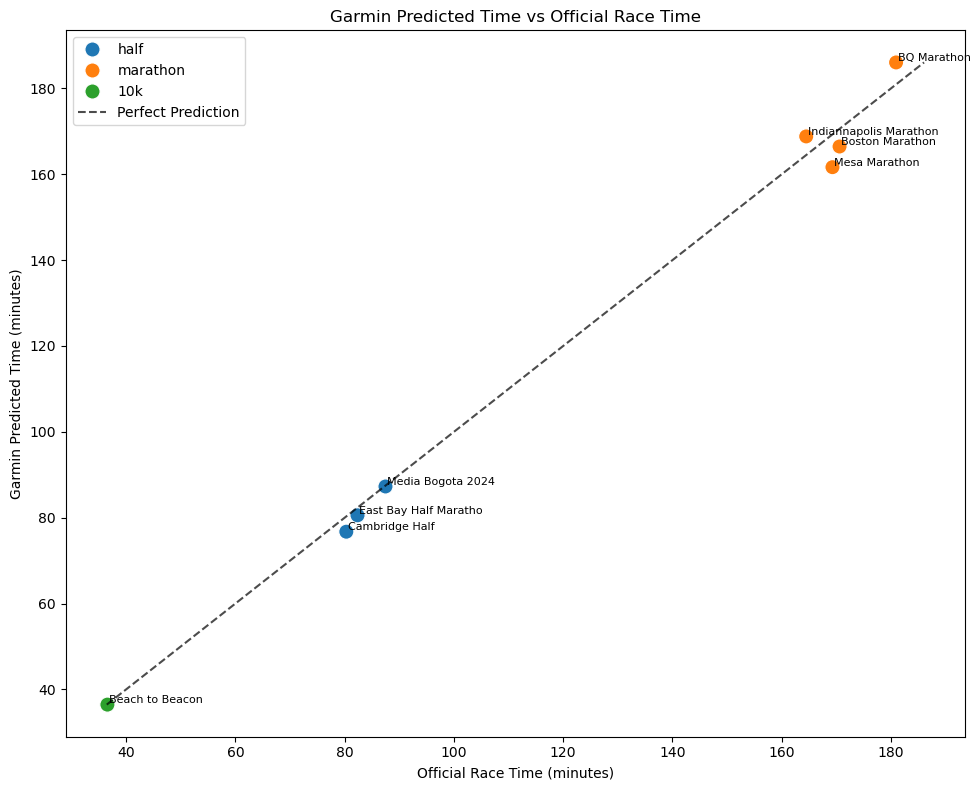

In [16]:
# Plot official time vs predicted time
plt.figure(figsize=(10, 8))

# Scatter plot
sns.scatterplot(
    data=race_prediction_eval_df,
    x="official_time_min",
    y="relevant_prediction",
    hue="race_type",
    s=120
)

# Perfect prediction reference line
min_val = min(
    race_prediction_eval_df["official_time_min"].min(),
    race_prediction_eval_df["relevant_prediction"].min()
)

max_val = max(
    race_prediction_eval_df["official_time_min"].max(),
    race_prediction_eval_df["relevant_prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    alpha=0.7,
    label="Perfect Prediction"
)

# Annotate race names
for _, row in race_prediction_eval_df.iterrows():

    if pd.notna(row["relevant_prediction"]):

        plt.text(
            row["official_time_min"] + 0.3,
            row["relevant_prediction"] + 0.3,
            row["label"],
            fontsize=8
        )

plt.title("Garmin Predicted Time vs Official Race Time")
plt.xlabel("Official Race Time (minutes)")
plt.ylabel("Garmin Predicted Time (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# === Scratch paper ===

